Accuracy: 0.7729166666666667

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.76      0.85       417
           1       0.35      0.89      0.51        63

    accuracy                           0.77       480
   macro avg       0.67      0.82      0.68       480
weighted avg       0.90      0.77      0.81       480



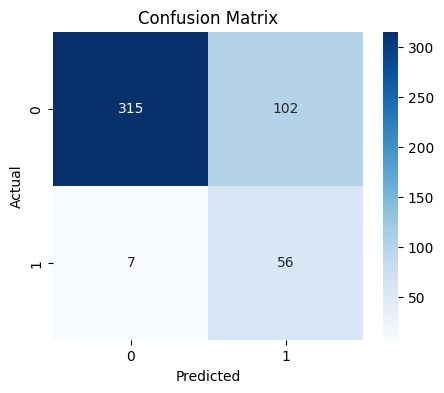

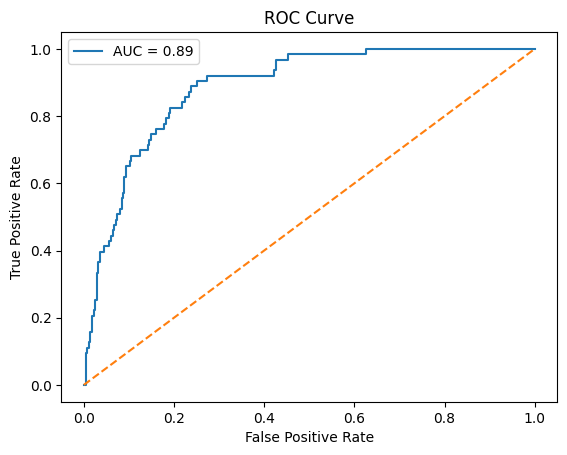

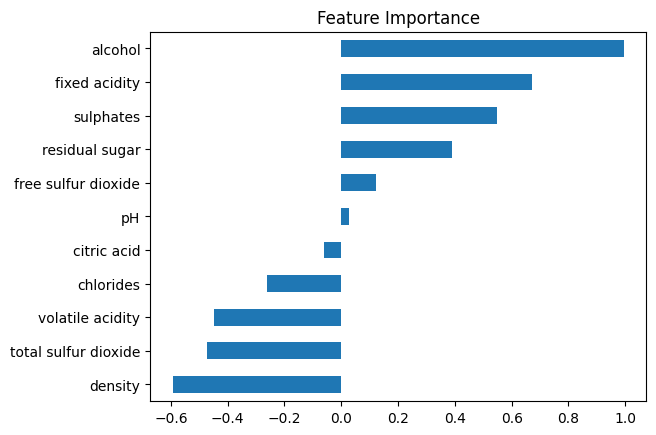

In [4]:
# ===============================
# IMPORT LIBRARIES
# ===============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, roc_auc_score

# ===============================
# LOAD DATA
# ===============================

wine = pd.read_csv(r"C:\Users\Ruhani narang\Downloads\winequality-red.csv")

# Create target variable
wine['goodquality'] = [1 if x >= 7 else 0 for x in wine['quality']]

# Features and Target
X = wine.drop(['quality','goodquality'], axis=1)
y = wine['goodquality']

# ===============================
# TRAIN TEST SPLIT
# ===============================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=7
)

# ===============================
# FEATURE SCALING (IMPORTANT)
# ===============================

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ===============================
# MODEL TRAINING
# ===============================

model = LogisticRegression(class_weight='balanced', max_iter=1000)

model.fit(X_train, y_train)

# ===============================
# PREDICTIONS
# ===============================

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

# ===============================
# EVALUATION
# ===============================

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# ===============================
# CONFUSION MATRIX
# ===============================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ===============================
# ROC CURVE
# ===============================

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

# ===============================
# FEATURE IMPORTANCE (LOGISTIC REGRESSION COEFFICIENTS)
# ===============================

importance = pd.Series(model.coef_[0], index=X.columns)
importance.sort_values().plot(kind='barh')
plt.title("Feature Importance")
plt.show()
